In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import io
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from kneed import KneeLocator

from yellowbrick.cluster import SilhouetteVisualizer

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('weatherHistory.csv', skiprows=range(1, 50000), nrows=3000)

df = df.drop(['Formatted Date', 'Summary', 'Precip Type', 'Loud Cover'], axis=1)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

label_enc = LabelEncoder()
ordinal_columns = df.select_dtypes('object').columns
for column in ordinal_columns:
    df[column] = label_enc.fit_transform(df[column])

iqr = df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)
lim = np.abs((df - df.median(numeric_only=True)) / iqr) < 2.22

df.loc[:, df.columns] = df.where(lim, np.nan)
df.dropna(inplace=True)

normalized_values = StandardScaler().fit_transform(df)
df = pd.DataFrame(normalized_values, columns=df.columns)

pca = PCA(2)
X = pca.fit_transform(df)

array([[<Axes: title={'center': 'Apparent Temperature (C)'}, xlabel='[Daily Summary]'>,
        <Axes: title={'center': 'Humidity'}, xlabel='[Daily Summary]'>],
       [<Axes: title={'center': 'Pressure (millibars)'}, xlabel='[Daily Summary]'>,
        <Axes: title={'center': 'Temperature (C)'}, xlabel='[Daily Summary]'>],
       [<Axes: title={'center': 'Visibility (km)'}, xlabel='[Daily Summary]'>,
        <Axes: title={'center': 'Wind Bearing (degrees)'}, xlabel='[Daily Summary]'>],
       [<Axes: title={'center': 'Wind Speed (km/h)'}, xlabel='[Daily Summary]'>,
        <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

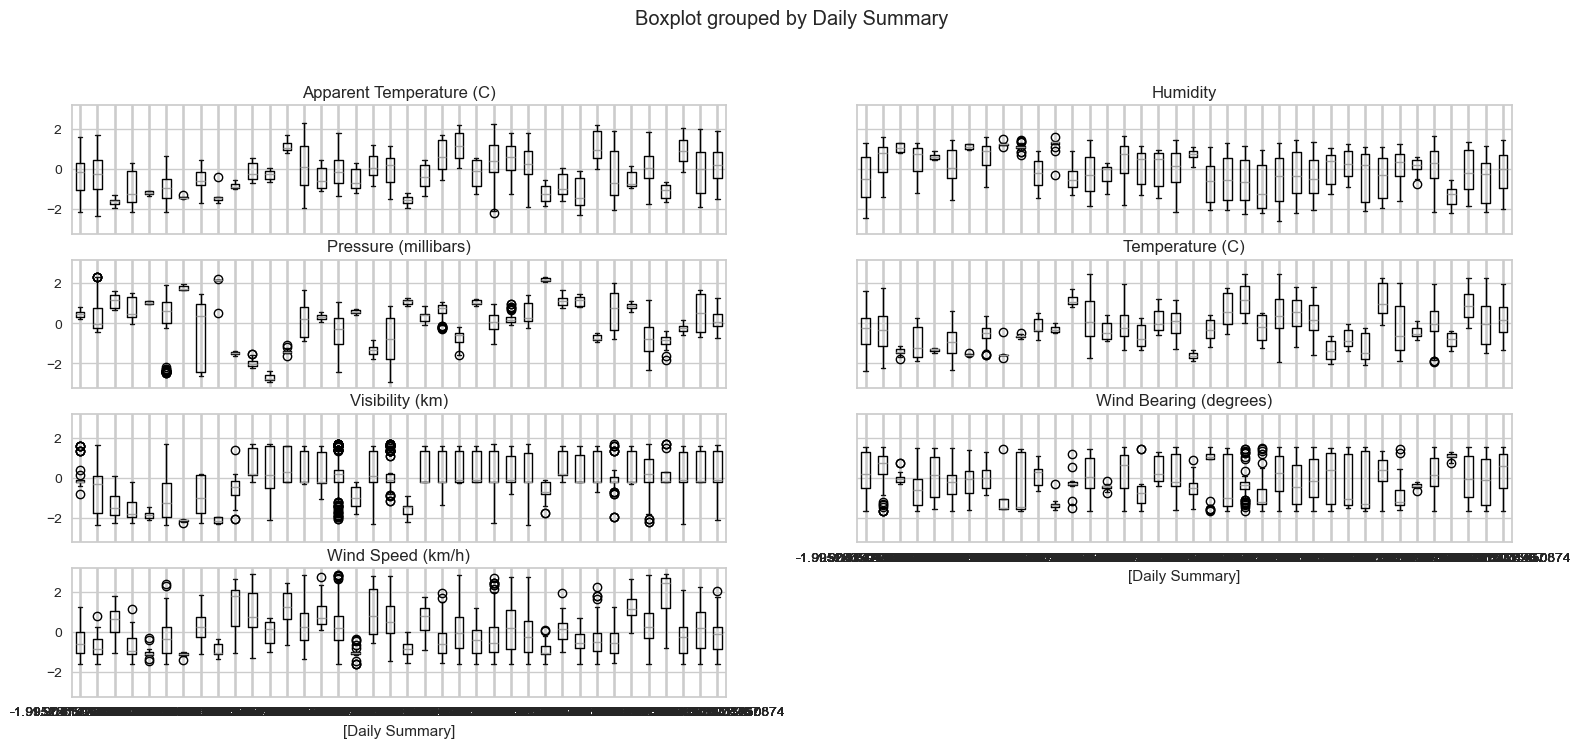

In [3]:
df.boxplot(by='Daily Summary', figsize=[18, 12], layout=[6,2])

In [4]:
n_clusters = range(2, 11, 1)
inertia_kmeans = []
inertia_kmedoids = []

clusters_scores = pd.DataFrame(columns=['N clusters', 'K-Means', 'K-Medoids'])

In [5]:
kmeans = KMeans()
kmedoids = KMedoids()

for n in n_clusters:
    kmeans = KMeans(n_clusters=n)
    kmedoids = kmedoids.set_params(n_clusters=n)

    kmeans_labels = kmeans.fit_predict(df)
    silhouette_kmeans = silhouette_score(df, kmeans_labels)

    kmedoids_labels = kmedoids.fit_predict(df)
    silhouette_kmedoids = silhouette_score(df, kmedoids_labels)

    inertia_kmeans.append(kmeans.inertia_)
    inertia_kmedoids.append(kmedoids.inertia_)

    new_row = pd.DataFrame({"N clusters": [n], "K-Means": [silhouette_kmeans], "K-Medoids": [silhouette_kmedoids]})
    clusters_scores = pd.concat([clusters_scores, new_row], ignore_index=True)

clusters_scores = clusters_scores.set_index('N clusters')
clusters_scores

,K-Means,K-Medoids
N clusters,,
2,0.207724,0.195383
3,0.204230,0.107758
4,0.197969,0.157855
5,0.194298,0.172919
6,0.191785,0.159770
7,0.184048,0.162810
8,0.178622,0.151460
9,0.179500,0.150657
10,0.182623,0.150314


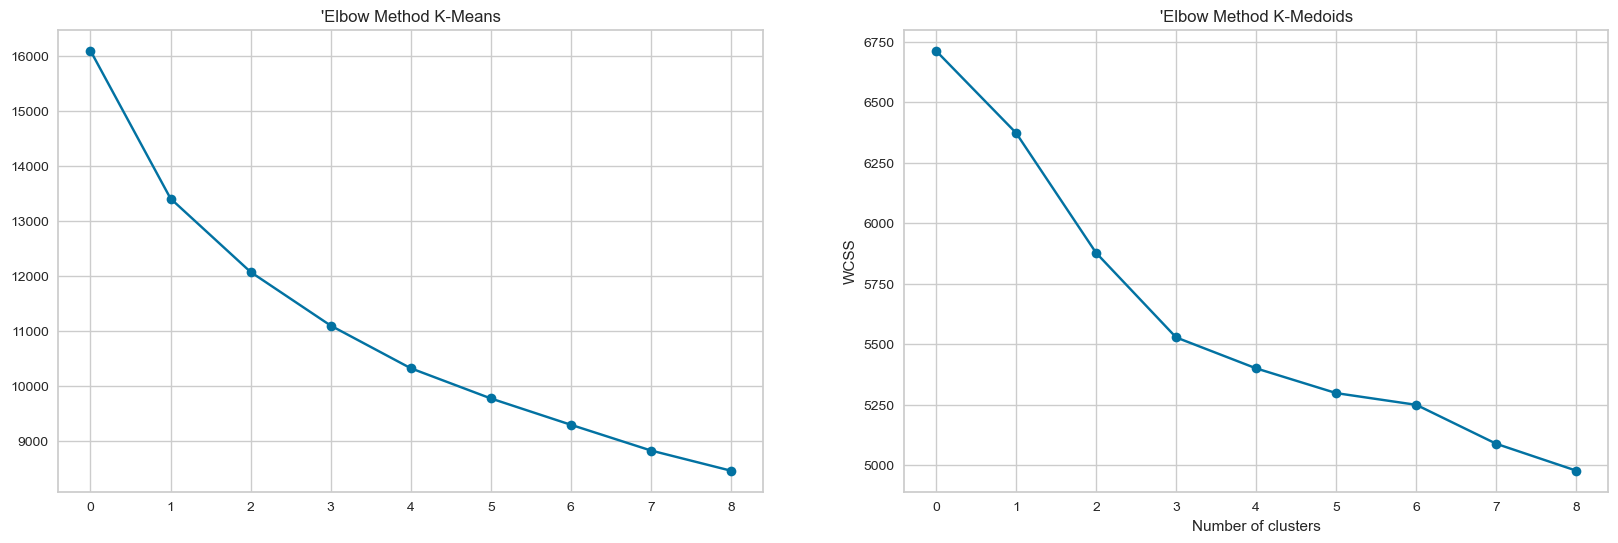

In [6]:
names = {'K-Means' : inertia_kmeans, 'K-Medoids' : inertia_kmedoids}

fig, axs = plt.subplots(ncols=2, figsize=(20, 6))
for ax, n in zip(axs, names):
    disp = ax.plot(names[n], 'bo-')
    ax.set_title( f"'Elbow Method {n}")
    
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') 
plt.show()

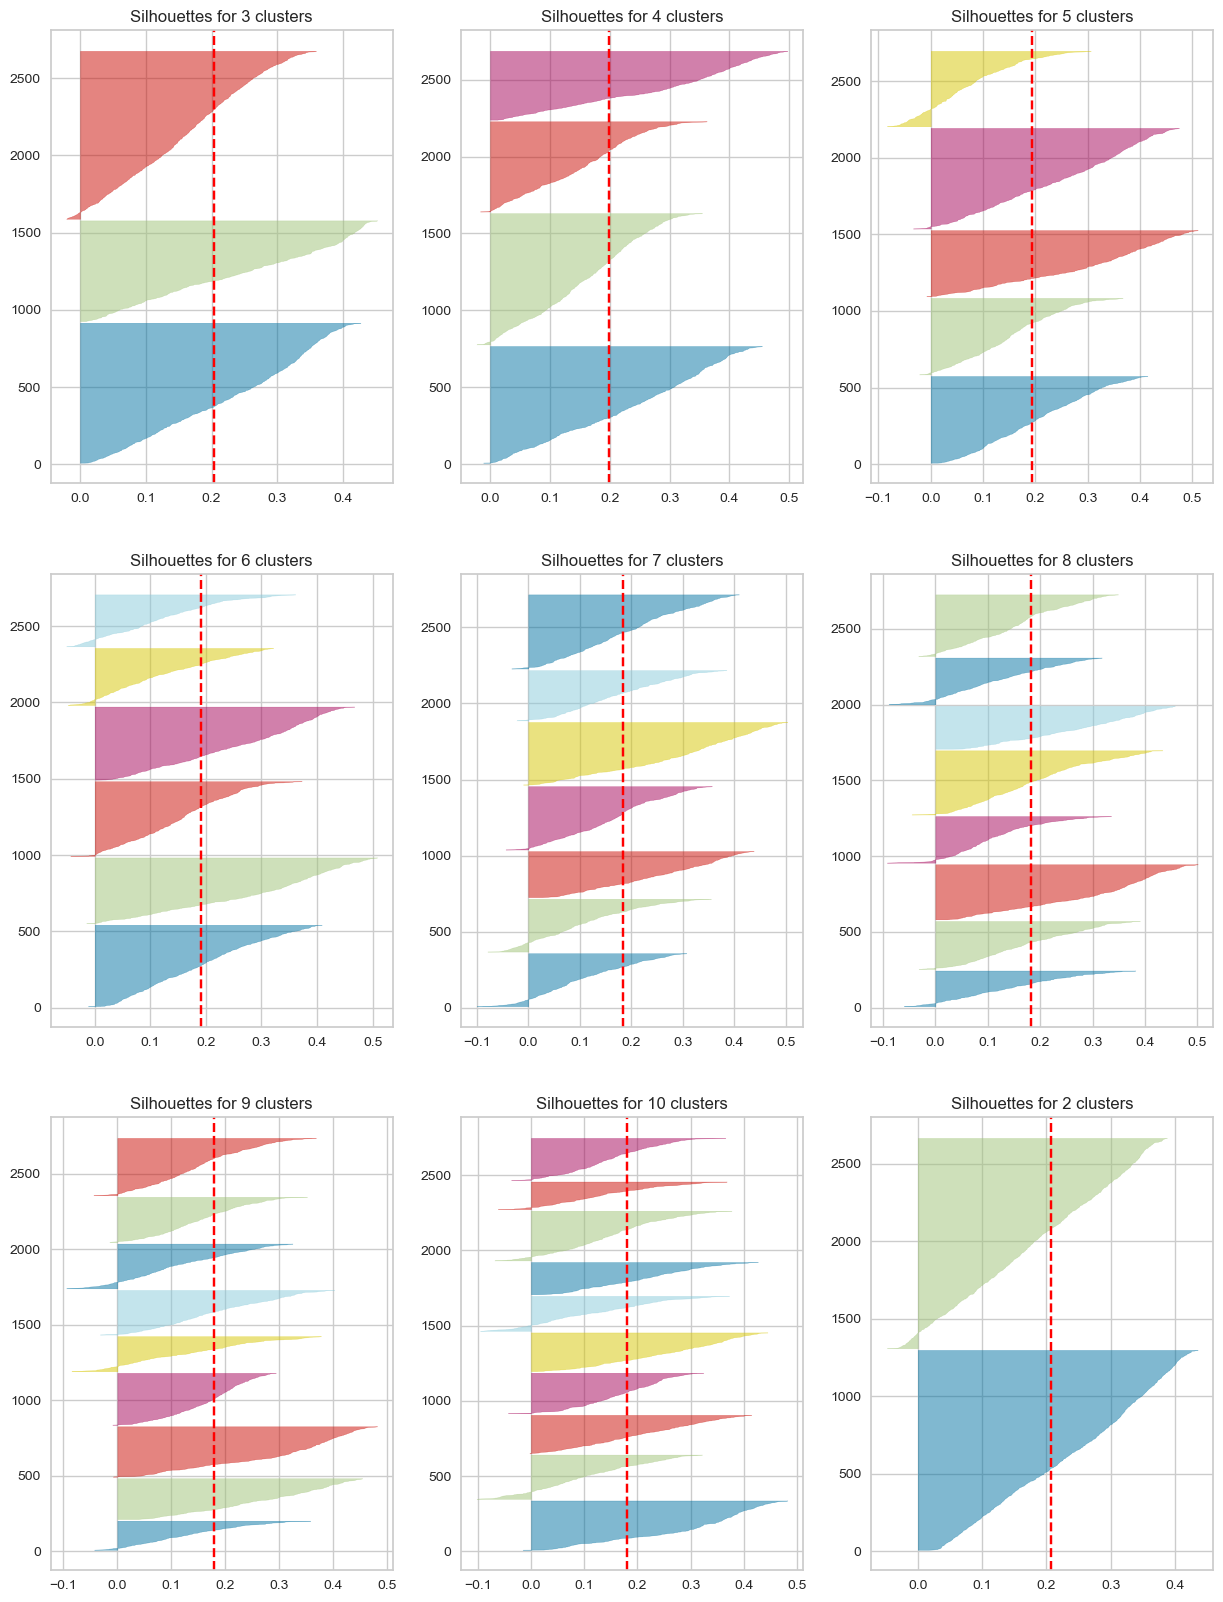

In [7]:
fig, ax = plt.subplots(3, 3, figsize=(15,20))
for n in n_clusters:
    kmeans = KMeans(n_clusters=n, random_state=42)
    q, mod = divmod(n, 3)
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(df)
    visualizer.set_title(f"Silhouettes for {n} clusters")

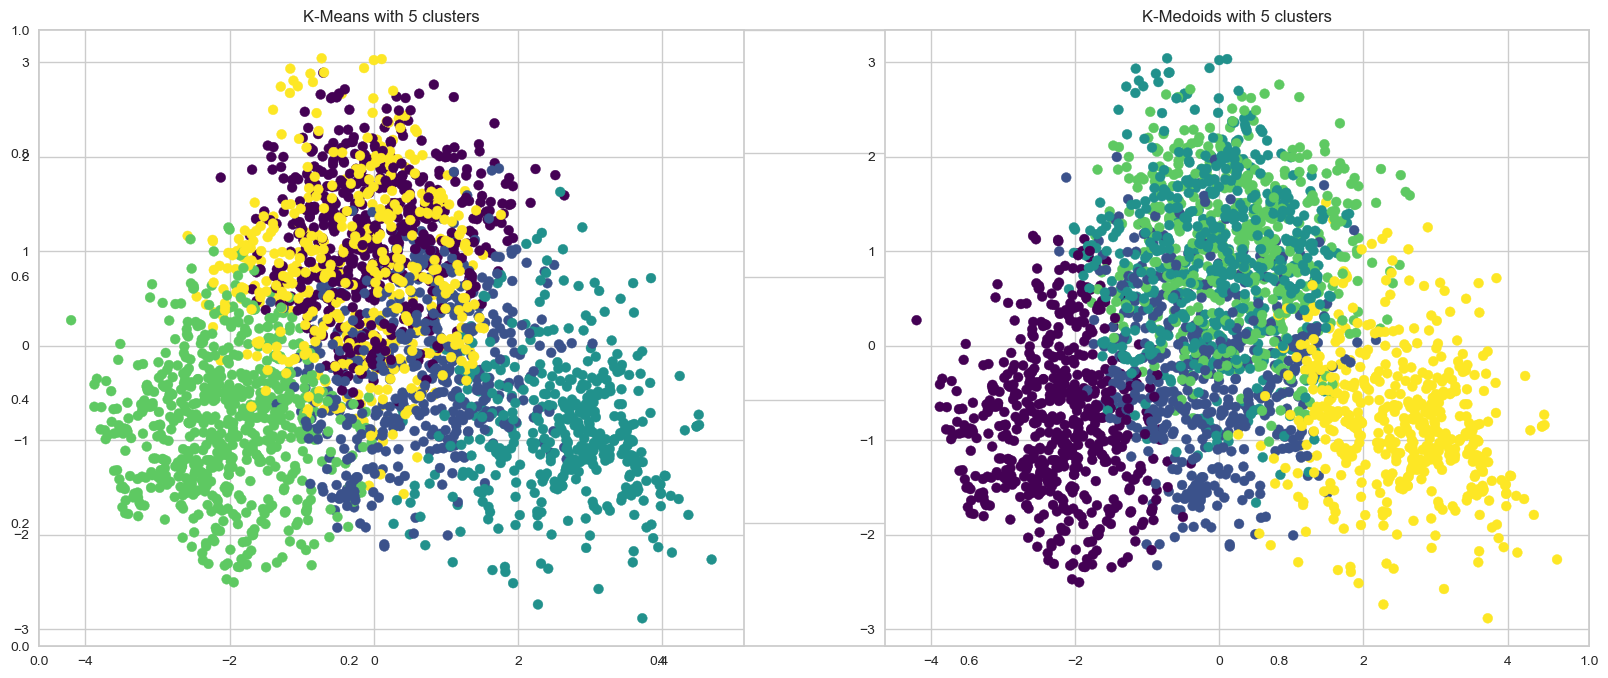

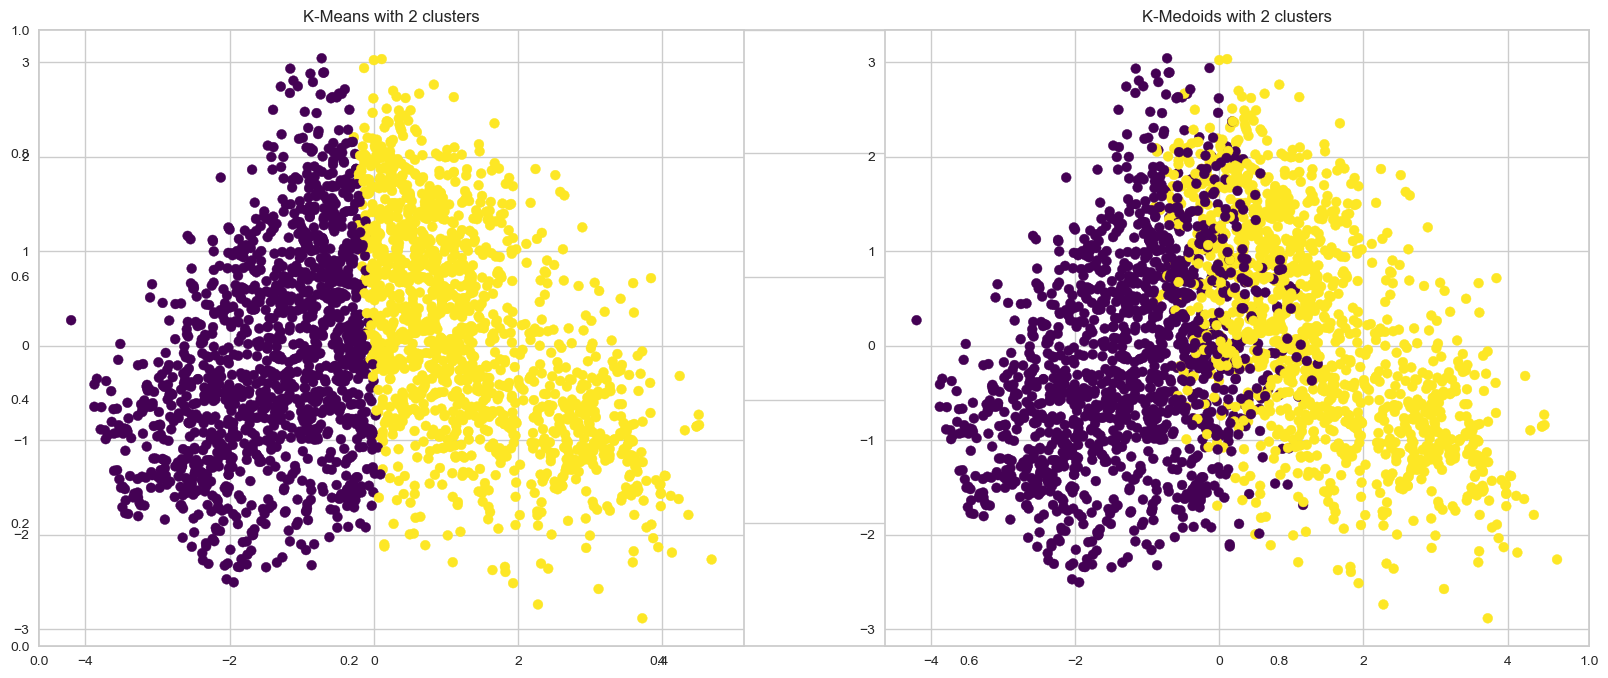

In [8]:
kmeans_opt = KneeLocator(n_clusters, inertia_kmeans, curve='convex', direction='decreasing').knee
kmedoids_opt = KneeLocator(n_clusters, inertia_kmedoids, curve='convex', direction='decreasing').knee

kmeans_sil_opt = clusters_scores['K-Means'].idxmax()
kmedoids_sil_opt = clusters_scores['K-Medoids'].idxmax()

opt_param = [[kmeans_opt, kmedoids_opt], [kmeans_sil_opt, kmedoids_sil_opt]]

for i in range(len(opt_param)): 
    kmeans = kmeans.set_params(n_clusters=opt_param[i][0])
    y_kmeans = kmeans.fit_predict(df)

    kmedoids = kmedoids.set_params(n_clusters=opt_param[i][1])
    y_kmedoids = kmedoids.fit_predict(df)

    plt.subplots(figsize=(20,8))
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
    plt.title(f"K-Means with {opt_param[i][0]} clusters")

    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=y_kmedoids, s=50, cmap='viridis')
    plt.title(f"K-Medoids with {opt_param[i][1]} clusters")
    plt.show()


In [9]:
clusters_est = pd.DataFrame()

for row in opt_param:
    kmeans = kmeans.set_params(n_clusters=row[0])
    y_kmeans = kmeans.fit_predict(df)

    kmedoids = kmedoids.set_params(n_clusters=row[1])
    y_kmedoids = kmedoids.fit_predict(df)

    new_row = pd.DataFrame({"Method" : [f'K-Means with {row[0]} clusters', f'K-Medoids with {row[0]} clusters'], 
                            f"Silhouette Score": [silhouette_score(df, y_kmeans), silhouette_score(df, y_kmedoids)], 
                            "Calinski-Harabasz Index": [calinski_harabasz_score(df, y_kmeans), calinski_harabasz_score(df, y_kmedoids)], 
                            "Davies-Bouldin Index": [davies_bouldin_score(df, y_kmeans), davies_bouldin_score(df, y_kmedoids)]})
                            
    clusters_est = pd.concat([clusters_est, new_row], ignore_index=True)

clusters_est

,Method,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,K-Means with 5 clusters,0.194246,599.812044,1.677235
1,K-Medoids with 5 clusters,0.172919,536.748769,1.834073
2,K-Means with 2 clusters,0.207670,835.529459,1.735266
3,K-Medoids with 2 clusters,0.195383,764.467993,1.816436


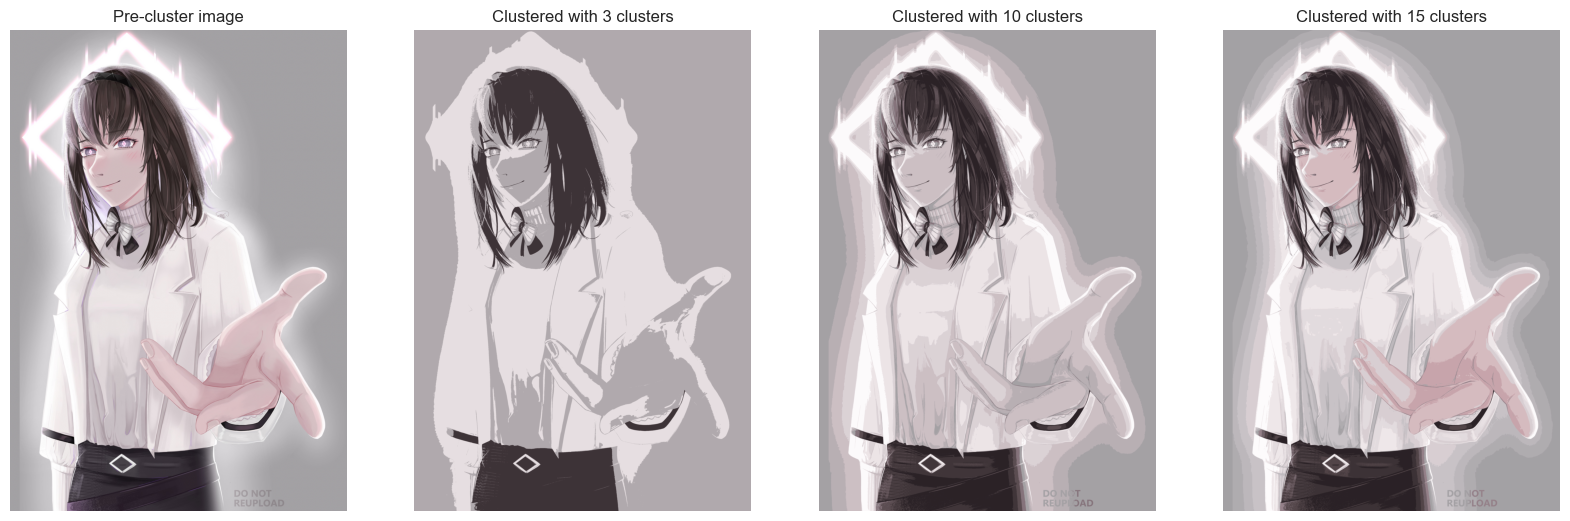

In [10]:
image = io.imread('priestess.jpg')
image = image / 255.0

pixels = image.reshape(-1, 3)
scaler = StandardScaler()
pixels_scaled = scaler.fit_transform(pixels)

i=1

plt.figure(figsize=(20, 12))
plt.subplot(1, 4, i)
plt.imshow(image)
plt.title("Pre-cluster image")
plt.axis('off')

img_clusters = [3, 10, 15]

for n in img_clusters:
    i+=1
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(pixels_scaled)

    segmented_image = kmeans.cluster_centers_[kmeans.labels_]
    segmented_image = scaler.inverse_transform(segmented_image)
    segmented_image = segmented_image.reshape(image.shape)
    
    plt.subplot(1, 4, i)
    plt.imshow(segmented_image)
    plt.title(f"Clustered with {n} clusters")
    plt.axis('off')

plt.show()